In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((218, 21101), (54, 21101), (218,), (54,))


Calculating SHAP values...
SHAP values shape: (54, 100, 5)
Selected features: 100

=== Overall Top 10 Features ===
      Feature  MeanAbsSHAP_MaxAcrossSubtypes
83     TRIML2                       0.025041
87      CST11                       0.020478
59    MIR520D                       0.019279
69  LOC727677                       0.018325
0      TMEM26                       0.018169
11      TTC36                       0.014287
21  LOC554203                       0.013720
98    TMEM207                       0.012640
16    GAL3ST3                       0.012458
24       CHD1                       0.012022


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


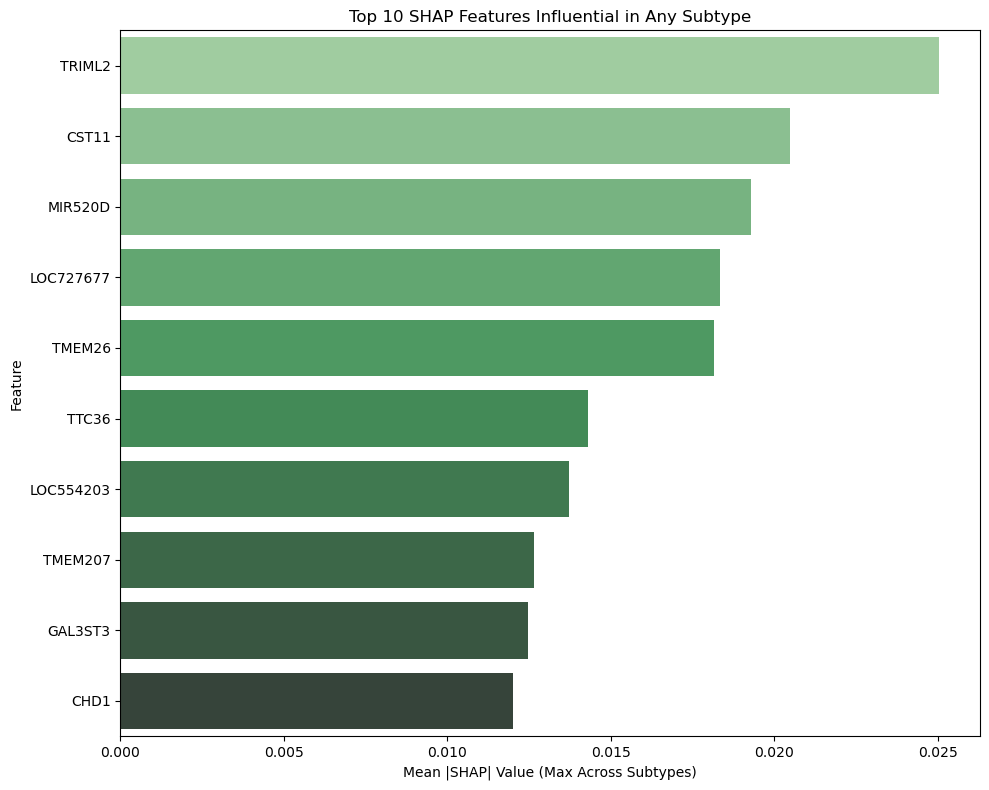

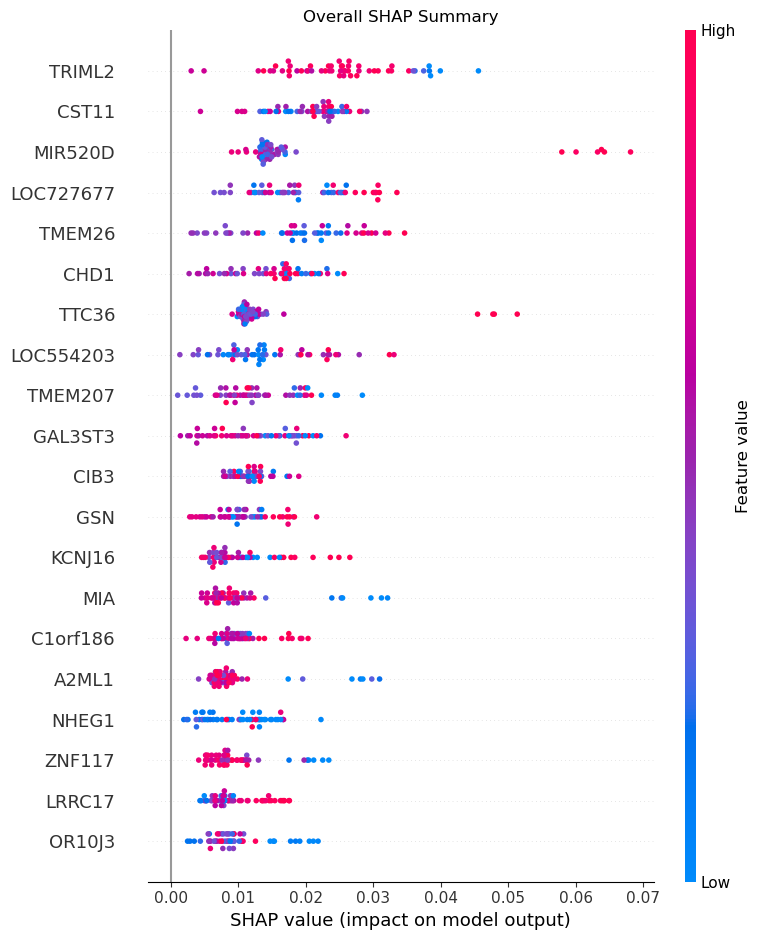


Subtype 1: Basal
      Feature  MeanAbsSHAP
59    MIR520D     0.019279
11      TTC36     0.014287
54      A2ML1     0.009920
69  LOC727677     0.009346
23       RNF2     0.009123
97        MIA     0.008058
17     KCNJ16     0.008030
7       KCNJ2     0.007447
92      REP15     0.007254
1      ZNF117     0.006718


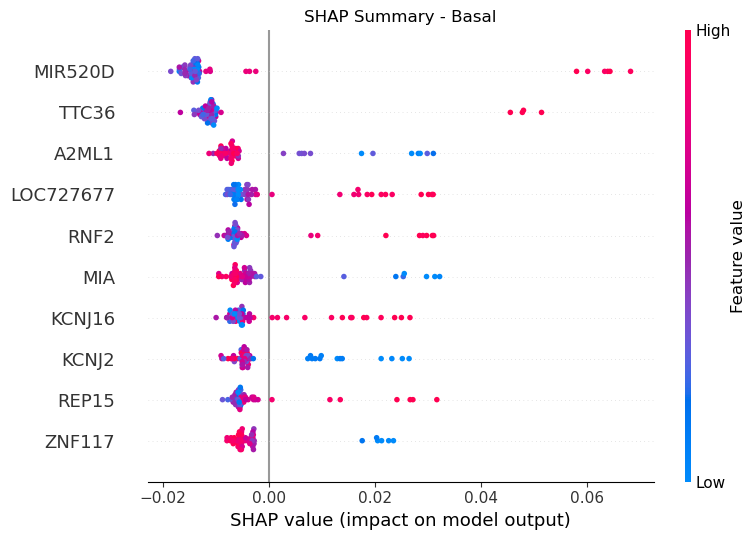

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


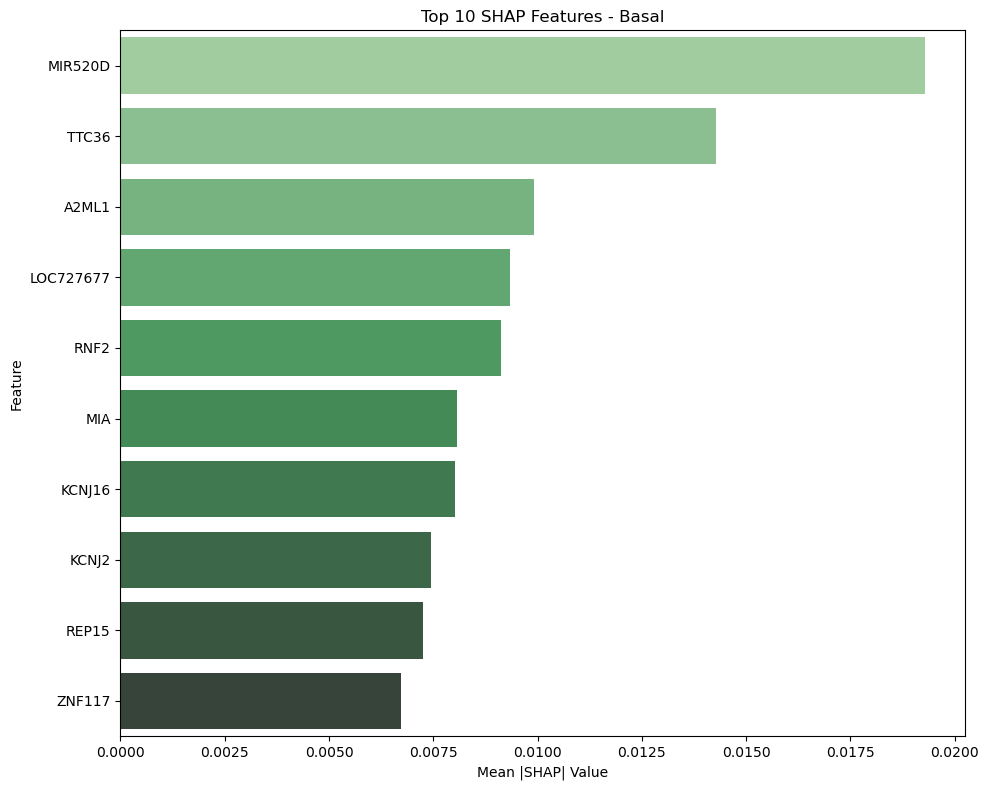


Subtype 2: Her2
      Feature  MeanAbsSHAP
0      TMEM26     0.018169
24       CHD1     0.010669
18       CIB3     0.010666
87      CST11     0.009982
69  LOC727677     0.008888
94   C1orf186     0.008809
80      NHEG1     0.007752
83     TRIML2     0.007644
34     LRRC17     0.007238
59    MIR520D     0.006802


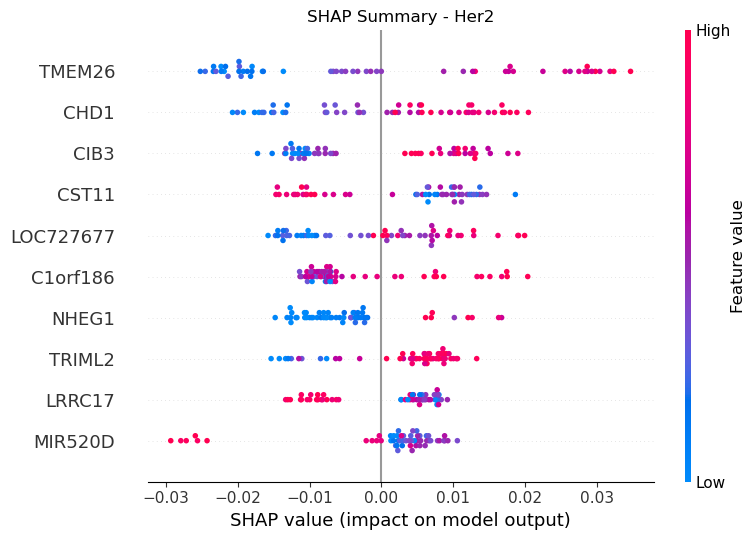

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


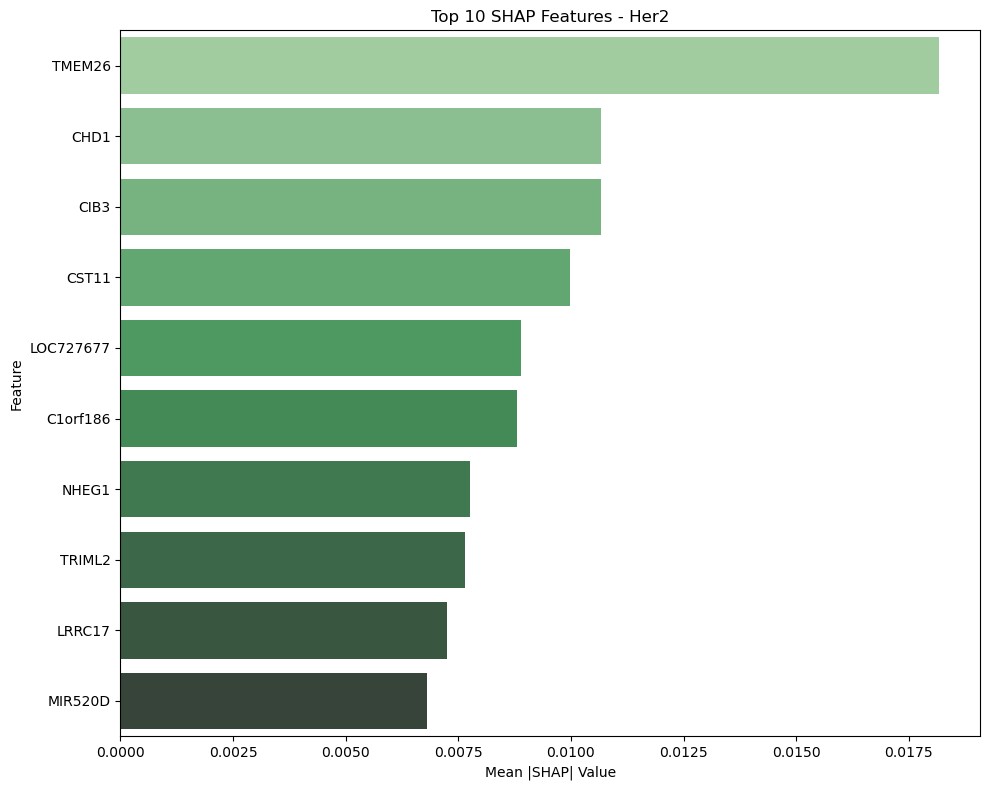


Subtype 3: LumA
      Feature  MeanAbsSHAP
69  LOC727677     0.018325
21  LOC554203     0.013720
16    GAL3ST3     0.012458
83     TRIML2     0.011001
19     TRIM34     0.009371
43    ECEL1P2     0.009245
0      TMEM26     0.008751
50      MAP1D     0.008681
24       CHD1     0.008493
80      NHEG1     0.008377


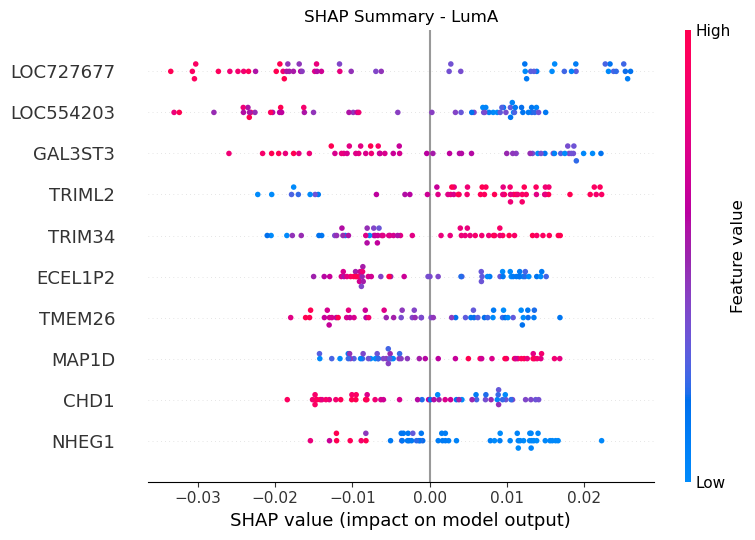

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


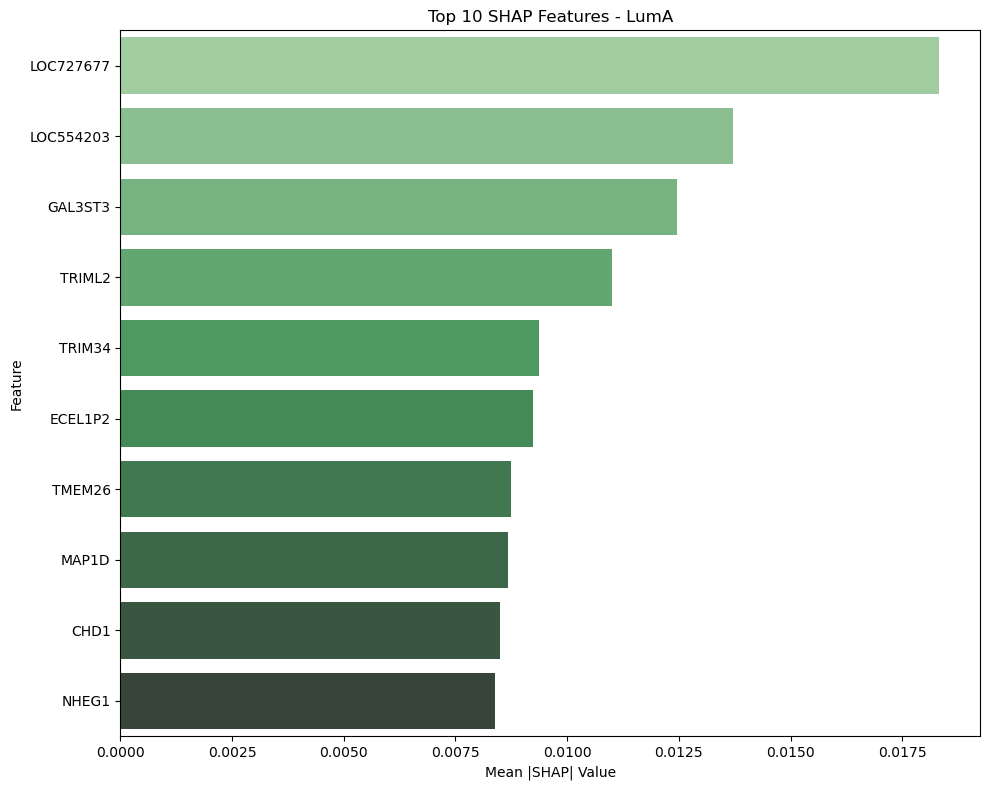


Subtype 4: LumB
      Feature  MeanAbsSHAP
83     TRIML2     0.025041
87      CST11     0.020478
0      TMEM26     0.013129
21  LOC554203     0.012648
98    TMEM207     0.012640
24       CHD1     0.012022
81        GSN     0.010633
94   C1orf186     0.009559
95     OR10J3     0.009474
34     LRRC17     0.009410


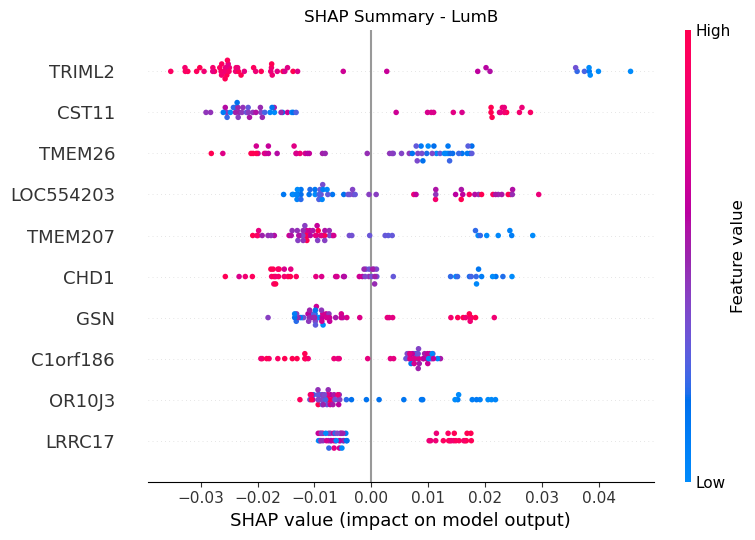

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


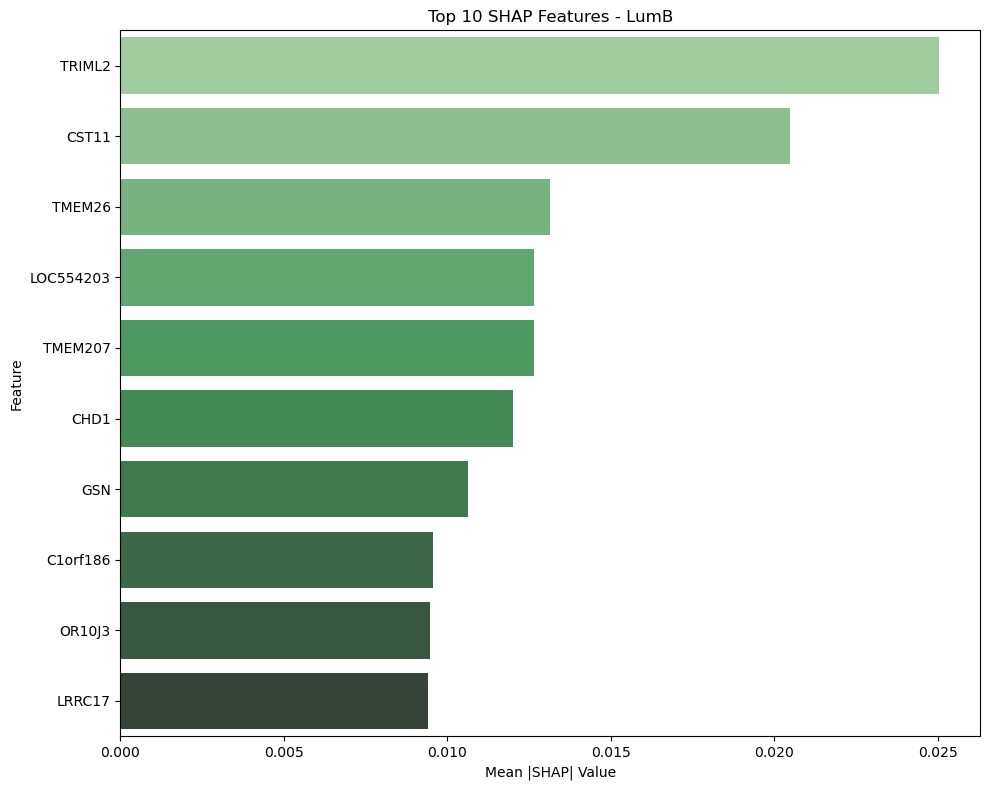


Subtype 5: Normal
     Feature  MeanAbsSHAP
87     CST11     0.005912
94  C1orf186     0.004648
24      CHD1     0.003980
59   MIR520D     0.003969
97       MIA     0.003966
64     FABP7     0.003631
2      SSBP2     0.003556
83    TRIML2     0.003263
90     TAGLN     0.003248
14     SCRG1     0.003219


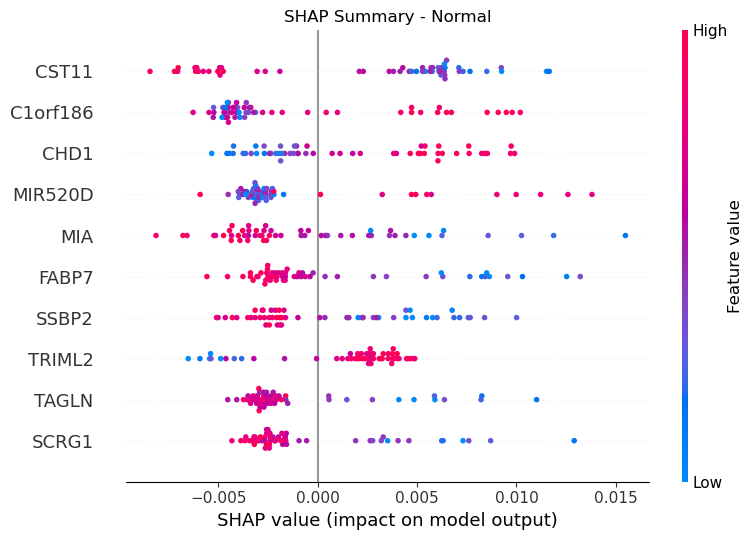

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_24248\1555283850.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


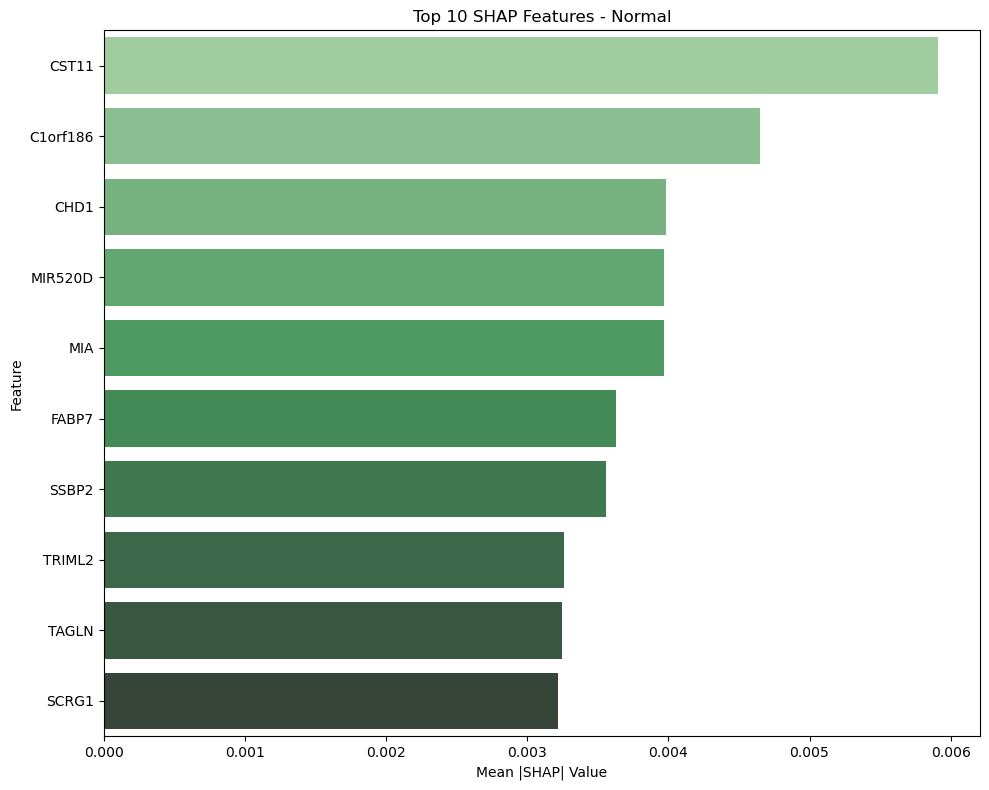


SHAP analysis complete — both overall and per-subtype results generated.


In [3]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_IP_IRUS_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

X_test_selected = X_test.values[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")